# EDA — Ethan

This notebook covers dataset inventory, label integrity check, sample-rate audit, per-emotion feature exploration, and a feature discrimination ranking to guide Sprint 2 preprocessing. All analysis runs against the merged Emotions dataset, which combines four corpora: TESS, RAVDESS, CREMA-D, and SAVEE.

In [1]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import re
import os
import soundfile as sf

%matplotlib inline
sns.set_theme(style='whitegrid')

## 1. Load file paths and labels

Uses the team's shared loading pattern: an `EMOTION_FOLDERS` list, a `FOLDER_TO_LABEL` dict, and a walk over each folder to build `df` with columns `file_path` and `emotion`.

In [2]:
DATASET_PATH = "/Users/sa27/Downloads/Emotions"

EMOTIONS = ["Angry", "Disgusted", "Fearful", "Happy", "Neutral", "Sad", "Suprised"]

EMOTION_FOLDERS = EMOTIONS

FOLDER_TO_LABEL = {
    "Angry":     "angry",
    "Disgusted": "disgusted",
    "Fearful":   "fearful",
    "Happy":     "happy",
    "Neutral":   "neutral",
    "Sad":       "sad",
    "Suprised":  "surprised",
}

file_paths = []
labels     = []

print('Loading file paths...\n')

for folder_name in EMOTION_FOLDERS:
    folder_path = os.path.join(DATASET_PATH, folder_name)

    if not os.path.isdir(folder_path):
        print(f'  ⚠️  Folder not found: {folder_path}')
        continue

    wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    label     = FOLDER_TO_LABEL[folder_name]

    for f in wav_files:
        file_paths.append(os.path.join(folder_path, f))
        labels.append(label)

    print(f'  📂 {folder_name:<12}  →  {len(wav_files):>5} files   (label: "{label}")')

df = pd.DataFrame({'file_path': file_paths, 'emotion': labels})
df['filename'] = df['file_path'].apply(os.path.basename)

print(f'\n✅ Master DataFrame ready.')
print(f'   Total files : {len(df):,}')
print(f'   Emotions    : {sorted(df["emotion"].unique())}')
print()
df.head(8)

Loading file paths...

  📂 Angry         →   2167 files   (label: "angry")
  📂 Disgusted     →   1863 files   (label: "disgusted")
  📂 Fearful       →   2047 files   (label: "fearful")
  📂 Happy         →   2167 files   (label: "happy")
  📂 Neutral       →   1795 files   (label: "neutral")
  📂 Sad           →   2167 files   (label: "sad")
  📂 Suprised      →    592 files   (label: "surprised")

✅ Master DataFrame ready.
   Total files : 12,798
   Emotions    : ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']



,file_path,emotion,filename
0,/Users/sa27/Downloads/Emotions/Angry/03-01-05-...,angry,03-01-05-01-02-01-16.wav
1,/Users/sa27/Downloads/Emotions/Angry/1022_ITS_...,angry,1022_ITS_ANG_XX.wav
2,/Users/sa27/Downloads/Emotions/Angry/1037_ITS_...,angry,1037_ITS_ANG_XX.wav
3,/Users/sa27/Downloads/Emotions/Angry/03-01-05-...,angry,03-01-05-01-02-01-02.wav
4,/Users/sa27/Downloads/Emotions/Angry/1018_IWL_...,angry,1018_IWL_ANG_XX.wav
5,/Users/sa27/Downloads/Emotions/Angry/1059_IEO_...,angry,1059_IEO_ANG_MD.wav
6,/Users/sa27/Downloads/Emotions/Angry/1048_IEO_...,angry,1048_IEO_ANG_HI.wav
7,/Users/sa27/Downloads/Emotions/Angry/OAF_king_...,angry,OAF_king_angry.wav


## 2. Source corpus inventory

The dataset merges four corpora — TESS, RAVDESS, CREMA-D, and SAVEE — and each contributes files to every emotion folder. We tag each clip by its source corpus from the filename pattern so we understand the composition of what we're actually working with.

Emotion × Source crosstab:
source     CREMA-D  RAVDESS  SAVEE  TESS
emotion                                 
angry         1271      376    120   400
disgusted     1271      192      0   400
fearful       1271      376      0   400
happy         1271      376    120   400
neutral       1087      188    120   400
sad           1271      376    120   400
surprised        0      192      0   400

Source counts:
source
CREMA-D    7442
TESS       2800
RAVDESS    2076
SAVEE       480
Name: count, dtype: int64


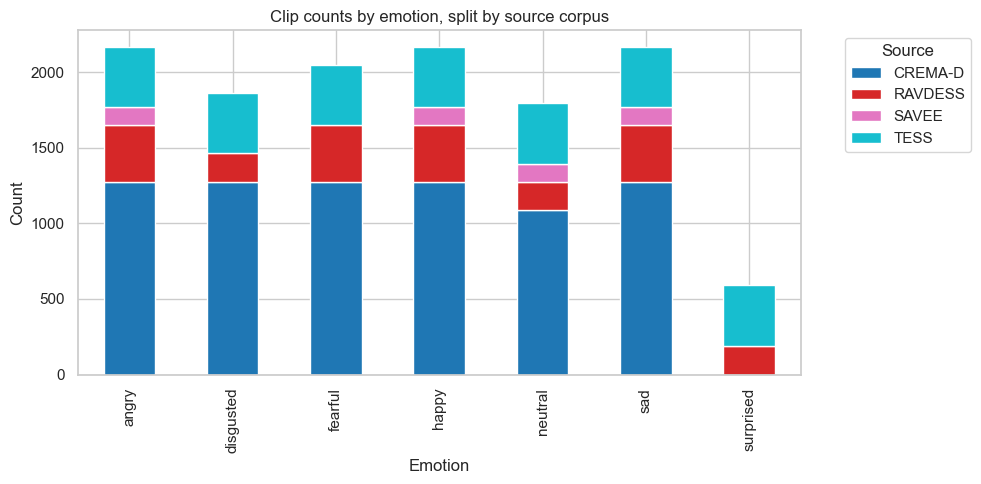

In [3]:
def detect_source(filename):
    if re.match(r'^(OAF_|YAF_|OA_)', filename):
        return 'TESS'
    elif re.match(r'^\d+-\d+-', filename):
        return 'RAVDESS'
    elif re.match(r'^\d{4}_[A-Z]', filename):
        return 'CREMA-D'
    elif re.match(r'^(sa|su|[adfhn])\d+\.wav$', filename):
        return 'SAVEE'
    else:
        return 'other'

df['source'] = df['filename'].apply(detect_source)

print('Emotion × Source crosstab:')
print(pd.crosstab(df['emotion'], df['source']))
print()
print('Source counts:')
print(df['source'].value_counts())

pivot = df.groupby(['emotion', 'source']).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab10')
plt.title('Clip counts by emotion, split by source corpus')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.legend(title='Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. The SAVEE folder-label problem

SAVEE has 4 speakers, 120 files each (480 total). When the dataset was assembled, SAVEE files were split across emotion folders by speaker, not by emotion. That means a file sitting in `Angry/` might actually be `sa14.wav` (sad). The true SAVEE emotion is encoded in the filename prefix: `a`=Angry, `d`=Disgusted, `f`=Fearful, `h`=Happy, `n`=Neutral, `sa`=Sad, `su`=Suprised.

**Conclusion:** for SAVEE files, relabel from the filename, not from the folder.

In [4]:
SAVEE_MAP = {
    'a':  'angry',
    'd':  'disgusted',
    'f':  'fearful',
    'h':  'happy',
    'n':  'neutral',
    'sa': 'sad',
    'su': 'surprised',
}

def decode_savee(filename):
    m = re.match(r'^(sa|su|[adfhn])(\d+)\.wav$', filename)
    if m:
        return SAVEE_MAP.get(m.group(1), 'unknown')
    return None

def true_emotion(row):
    if row['source'] == 'SAVEE':
        decoded = decode_savee(row['filename'])
        return decoded if decoded else row['emotion']
    return row['emotion']

df['true_emotion'] = df.apply(true_emotion, axis=1)

savee_df = df[df['source'] == 'SAVEE'].copy()
print('SAVEE: folder label vs true label (from filename):')
print(pd.crosstab(savee_df['emotion'], savee_df['true_emotion'],
                  rownames=['folder label'], colnames=['true label']))

mislabeled = (savee_df['emotion'] != savee_df['true_emotion']).sum()
total_savee = len(savee_df)
print(f'\nSAVEE total  : {total_savee}')
print(f'Mislabeled   : {mislabeled} ({mislabeled/total_savee:.1%}) if using folder name as label')

SAVEE: folder label vs true label (from filename):
true label    angry  disgusted  fearful  happy  neutral  sad  surprised
folder label                                                           
angry            15         15       15     15       30   15         15
happy            15         15       15     15       30   15         15
neutral          15         15       15     15       30   15         15
sad              15         15       15     15       30   15         15

SAVEE total  : 480
Mislabeled   : 405 (84.4%) if using folder name as label


## 4. Sample rate audit

The four corpora were recorded at different native sample rates. Resampling *up* does not recover information that wasn't recorded, so the honest preprocessing choice is to standardize *down*. CREMA-D's native rate (16 kHz) is the floor and represents the majority of files, so we standardize every clip to 16 kHz — giving each clip an equal 0–8 kHz bandwidth.

Sample rate by source:
            mean    min    max  nunique
source                                 
CREMA-D  16000.0  16000  16000        1
RAVDESS  48000.0  48000  48000        1
SAVEE    44100.0  44100  44100        1
TESS     24414.0  24414  24414        1


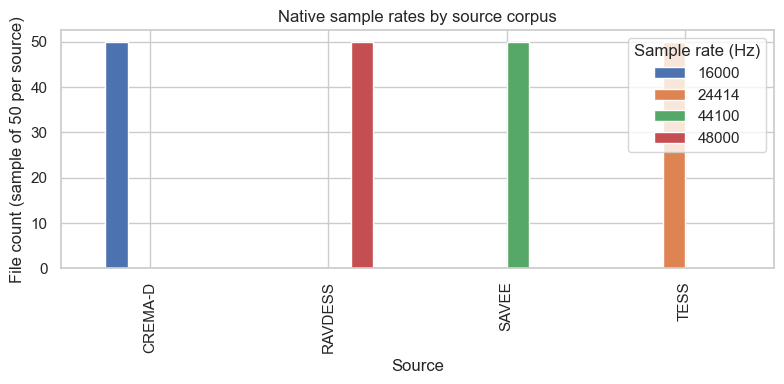

In [5]:
sample_per_source = df.groupby('source').sample(n=50, random_state=42)

sr_rows = []
for _, row in sample_per_source.iterrows():
    try:
        info = sf.info(row['file_path'])
        sr_rows.append({'source': row['source'], 'sample_rate': info.samplerate})
    except Exception:
        pass

sr_df = pd.DataFrame(sr_rows)
print('Sample rate by source:')
print(sr_df.groupby('source')['sample_rate'].agg(['mean', 'min', 'max', 'nunique']))

summary = sr_df.groupby(['source', 'sample_rate']).size().reset_index(name='count')
pivot_sr = summary.pivot(index='source', columns='sample_rate', values='count').fillna(0)
pivot_sr.plot(kind='bar', figsize=(8, 4))
plt.title('Native sample rates by source corpus')
plt.xlabel('Source')
plt.ylabel('File count (sample of 50 per source)')
plt.legend(title='Sample rate (Hz)')
plt.tight_layout()
plt.show()

## 5. Duration distribution

Clip duration drives the pad/trim window decision in Sprint 2 preprocessing. We want the window wide enough to capture most clips without padding too aggressively.

/opt/miniconda3/envs/ds_class/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


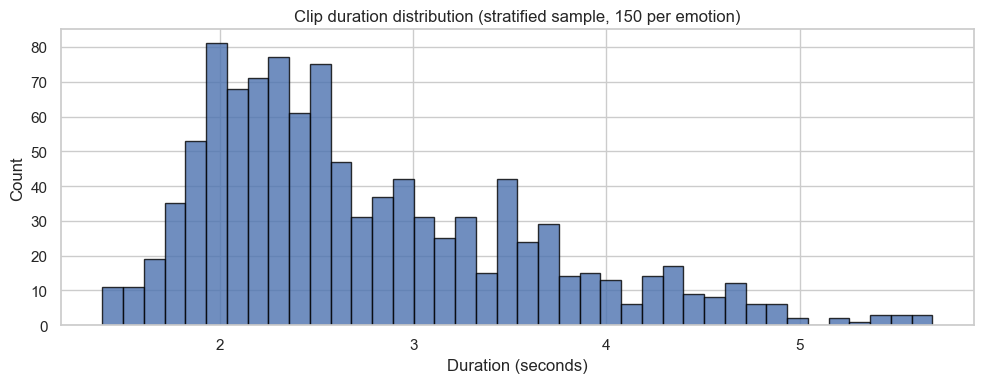

Duration percentiles:
  min    : 1.39s
  25%    : 2.14s
  median : 2.50s
  mean   : 2.75s
  75%    : 3.27s
  95%    : 4.40s
  max    : 5.69s


In [6]:
dur_sample = df.groupby('emotion').sample(n=150, random_state=42).copy()

durations = []
for _, row in dur_sample.iterrows():
    try:
        d = librosa.get_duration(path=row['file_path'])
        durations.append(d)
    except Exception:
        durations.append(None)

dur_sample['duration'] = durations
dur_sample = dur_sample.dropna(subset=['duration'])

plt.figure(figsize=(10, 4))
plt.hist(dur_sample['duration'], bins=40, edgecolor='black', alpha=0.8)
plt.title('Clip duration distribution (stratified sample, 150 per emotion)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

d = dur_sample['duration']
print('Duration percentiles:')
print(f'  min    : {d.min():.2f}s')
print(f'  25%    : {d.quantile(0.25):.2f}s')
print(f'  median : {d.median():.2f}s')
print(f'  mean   : {d.mean():.2f}s')
print(f'  75%    : {d.quantile(0.75):.2f}s')
print(f'  95%    : {d.quantile(0.95):.2f}s')
print(f'  max    : {d.max():.2f}s')

## 6. Per-emotion feature exploration

We pick one representative non-SAVEE clip per emotion and visualise how each acoustic feature looks across all seven emotions. Features examined: waveform, mel-spectrogram, MFCCs, RMS energy, pitch (F0), spectral centroid, zero-crossing rate, and chroma.

In [7]:
non_savee = df[df['source'] != 'SAVEE']
reps = non_savee.groupby('emotion').first().reset_index()

clips = {}
for _, row in reps.iterrows():
    emotion = row['emotion']
    path    = row['file_path']
    y, sr   = librosa.load(path, sr=22050)
    clips[emotion] = (y, sr)
    dur = librosa.get_duration(y=y, sr=sr)
    print(f'  {emotion:<12}: {os.path.basename(path)}  ({dur:.2f}s)')

EMOTION_LIST = list(clips.keys())

  angry       : 03-01-05-01-02-01-16.wav  (3.90s)
  disgusted   : 1073_IOM_DIS_XX.wav  (2.87s)
  fearful     : 03-01-06-01-02-02-02.wav  (3.74s)
  happy       : YAF_wire_happy.wav  (2.08s)
  neutral     : 1060_ITS_NEU_XX.wav  (2.40s)
  sad         : 1078_IWL_SAD_XX.wav  (2.44s)
  surprised   : 03-01-08-01-01-01-14.wav  (3.64s)


### 6.1 Waveform

The raw amplitude envelope shows how energy is distributed over time. High-arousal emotions (Angry, Happy) tend to have sustained high amplitude; low-arousal ones (Neutral, Sad) show quieter, more even envelopes.

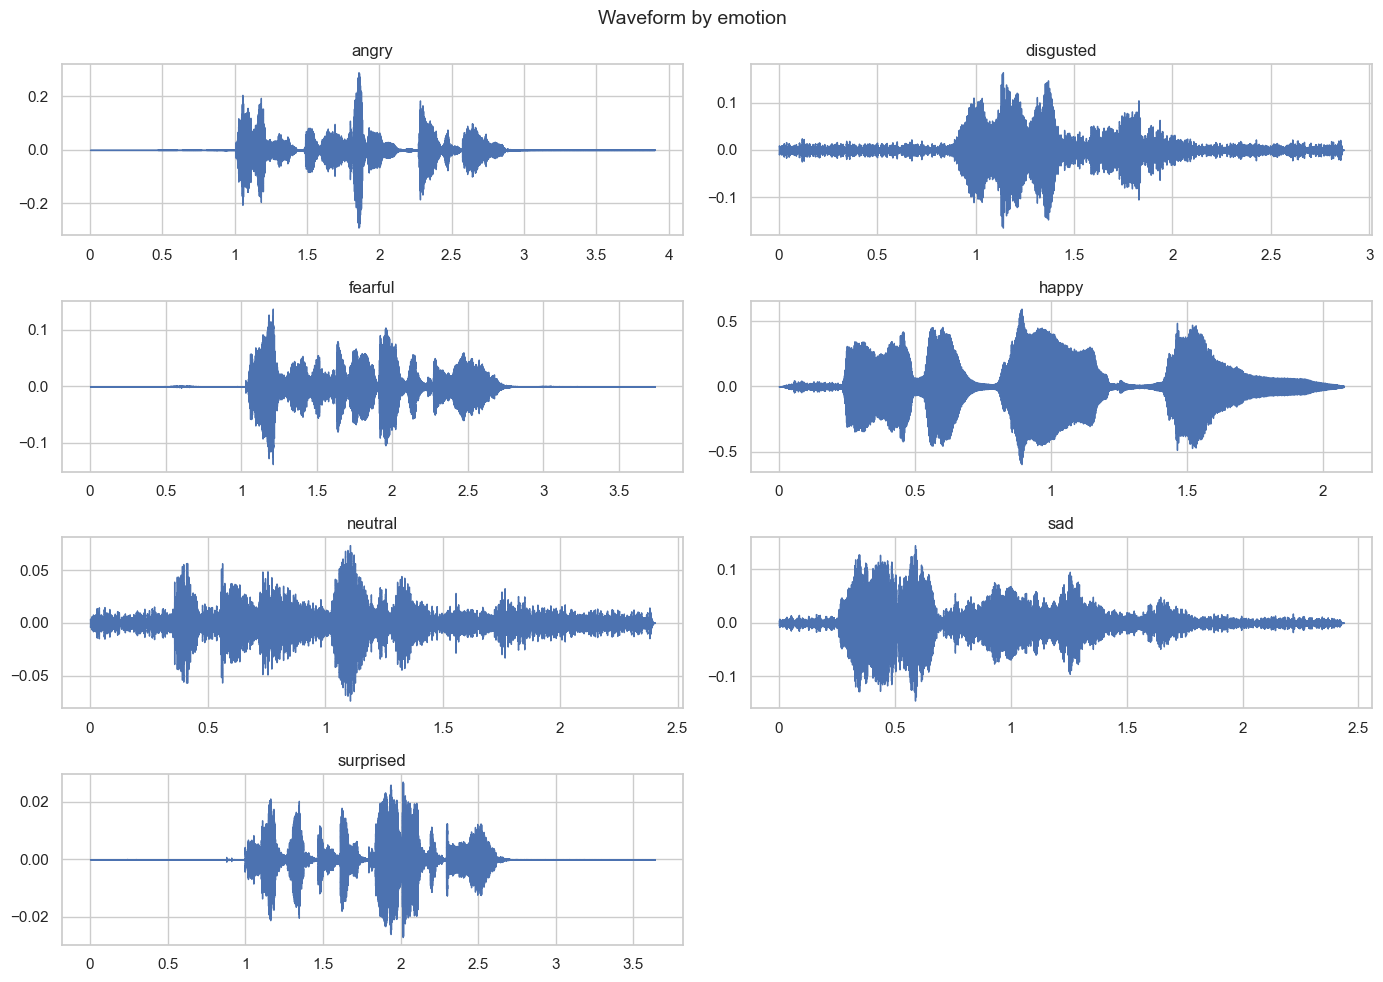

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
for ax, emotion in zip(axes.ravel(), EMOTION_LIST):
    y, sr = clips[emotion]
    librosa.display.waveshow(y, sr=sr, ax=ax)
    ax.set_title(emotion)
    ax.set_xlabel('')
axes.ravel()[-1].axis('off')
fig.suptitle('Waveform by emotion', fontsize=14)
plt.tight_layout()
plt.show()

### 6.2 Mel-spectrogram

The mel-spectrogram maps energy across perceptually-scaled frequency bins over time. It captures both the spectral shape and temporal dynamics that MFCCs summarise as coefficients. High-energy upper frequencies are a marker of Angry and Fearful speech.

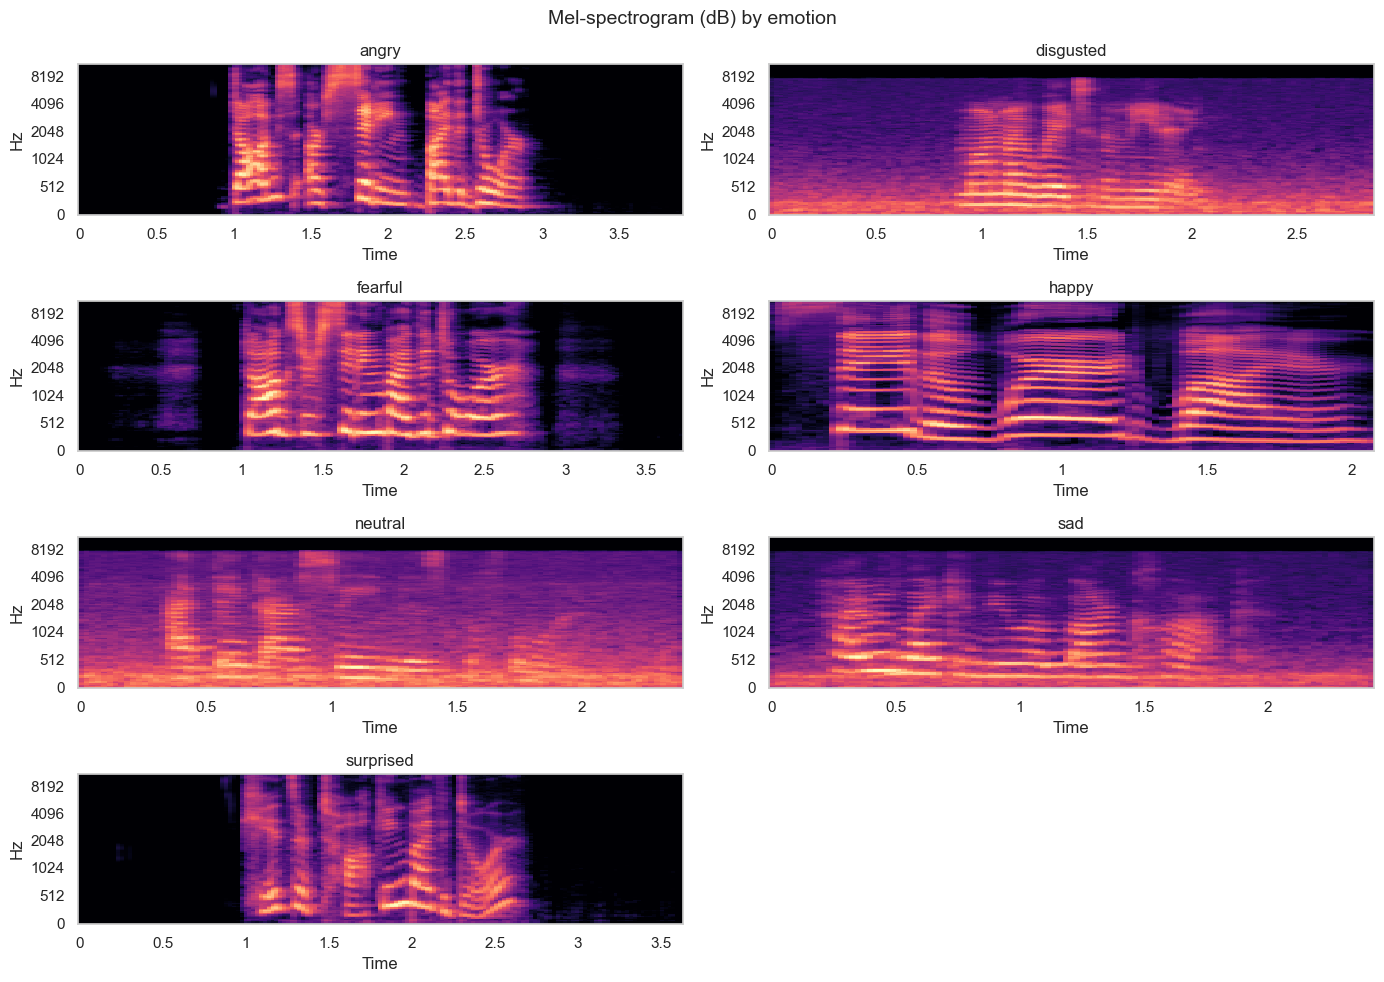

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
for ax, emotion in zip(axes.ravel(), EMOTION_LIST):
    y, sr = clips[emotion]
    S     = librosa.feature.melspectrogram(y=y, sr=sr)
    S_dB  = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, ax=ax, x_axis='time', y_axis='mel')
    ax.set_title(emotion)
axes.ravel()[-1].axis('off')
fig.suptitle('Mel-spectrogram (dB) by emotion', fontsize=14)
plt.tight_layout()
plt.show()

### 6.3 MFCCs (n=13)

Mel-frequency cepstral coefficients compress the spectral shape into 13 numbers per frame. The low-order coefficients (1–5) capture the broad spectral envelope and are the strongest emotion discriminators we'll confirm in Section 7.

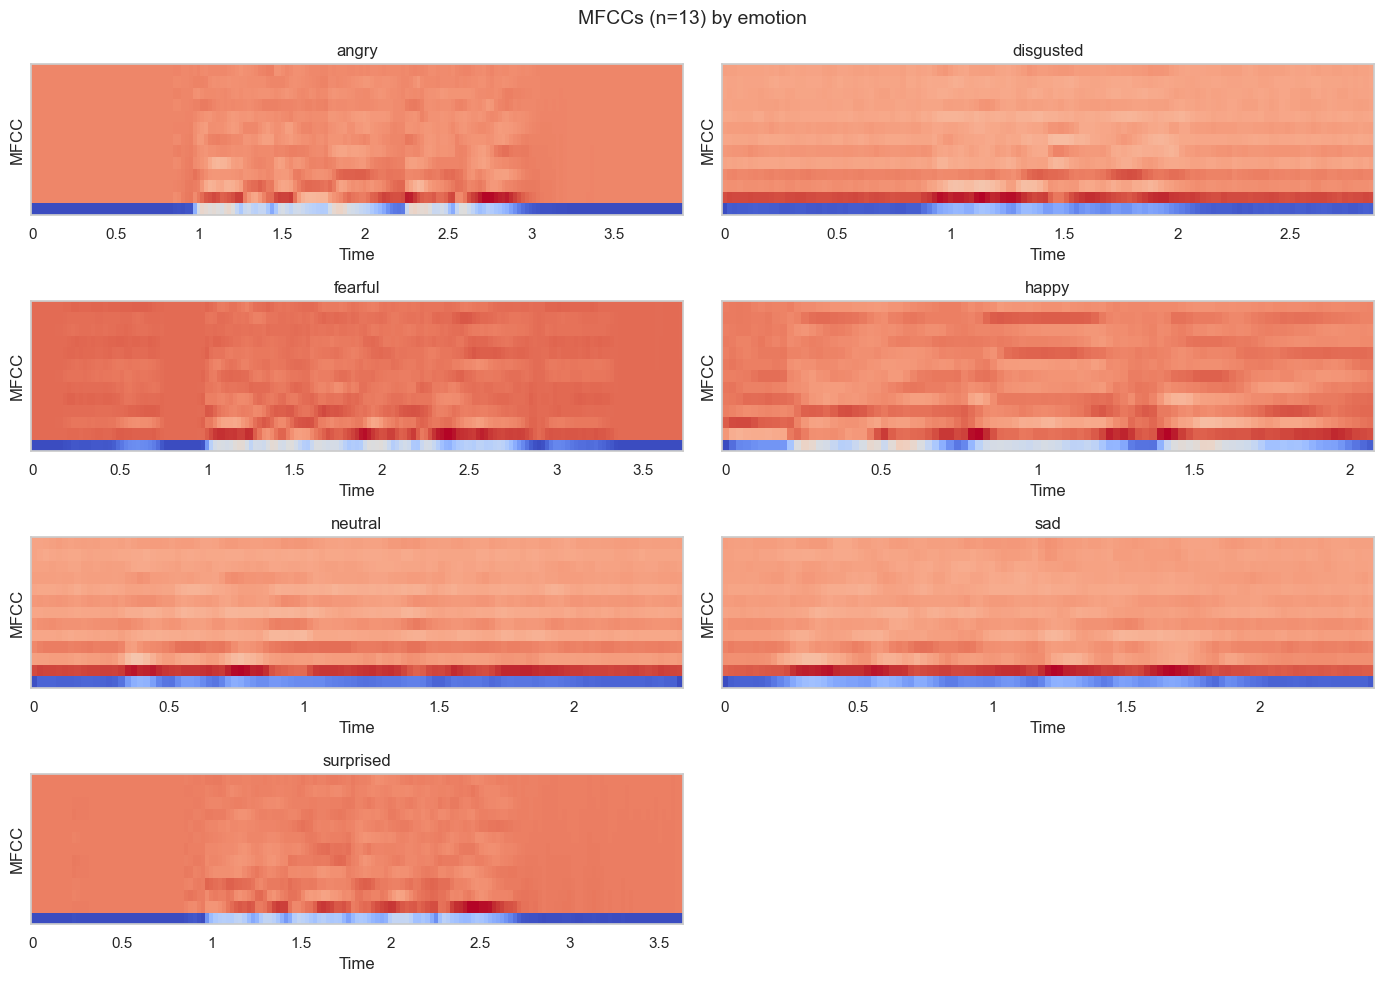

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
for ax, emotion in zip(axes.ravel(), EMOTION_LIST):
    y, sr  = clips[emotion]
    mfccs  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfccs, sr=sr, ax=ax, x_axis='time')
    ax.set_title(emotion)
    ax.set_ylabel('MFCC')
axes.ravel()[-1].axis('off')
fig.suptitle('MFCCs (n=13) by emotion', fontsize=14)
plt.tight_layout()
plt.show()

### 6.4 RMS energy

Root-mean-square energy is the frame-level loudness signal. It tracks arousal closely: Angry and Happy show high, sustained RMS; Sad and Neutral are lower and flatter.

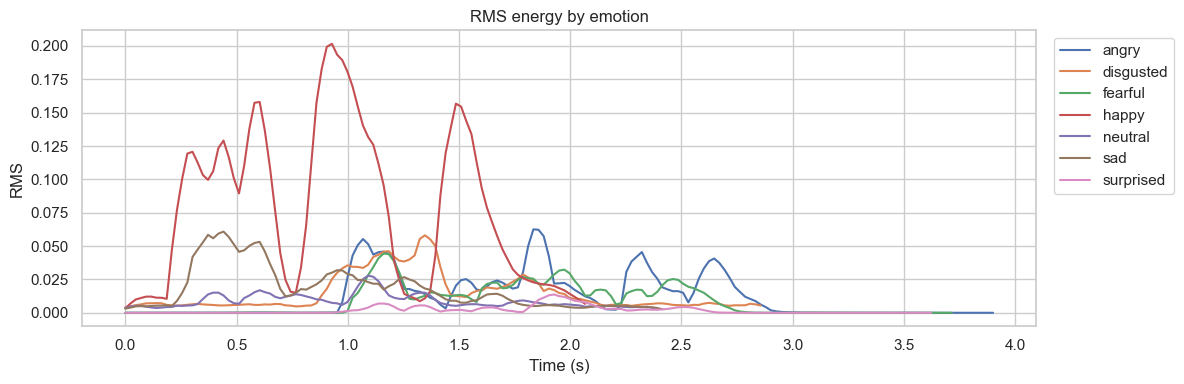

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
for emotion in EMOTION_LIST:
    y, sr = clips[emotion]
    rms   = librosa.feature.rms(y=y)[0]
    times = librosa.times_like(rms, sr=sr)
    ax.plot(times, rms, label=emotion)
ax.set_title('RMS energy by emotion')
ax.set_xlabel('Time (s)')
ax.set_ylabel('RMS')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6.5 Pitch (F0)

Fundamental frequency (F0) tracks perceived pitch. Fearful and Happy speech typically has higher and more variable F0; Sad has a lower, more monotone F0. Unvoiced frames (pauses, fricatives) are masked out before plotting.

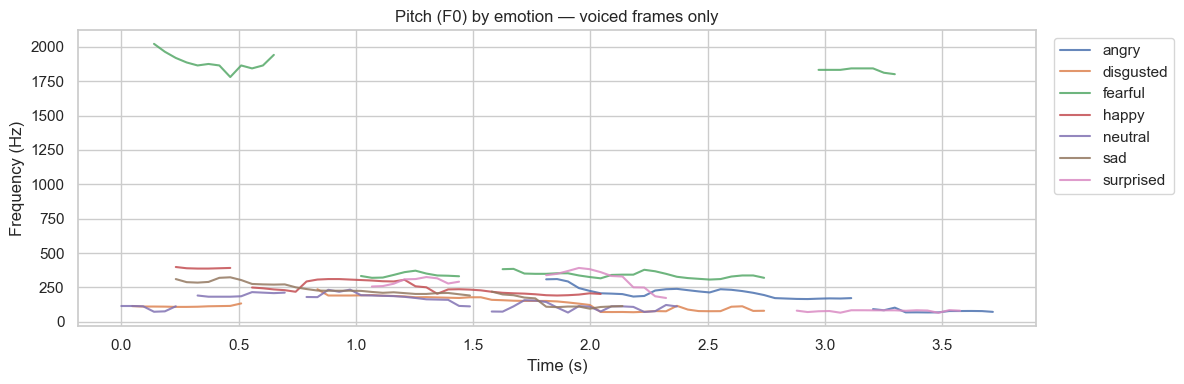

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
for emotion in EMOTION_LIST:
    y, sr = clips[emotion]
    f0, voiced_flag, _ = librosa.pyin(
        y,
        fmin=librosa.note_to_hz('C2'),
        fmax=librosa.note_to_hz('C7'),
        hop_length=1024
    )
    times     = librosa.times_like(f0, sr=sr, hop_length=1024)
    f0_voiced = np.where(voiced_flag, f0, np.nan)
    ax.plot(times, f0_voiced, label=emotion, alpha=0.85)
ax.set_title('Pitch (F0) by emotion — voiced frames only')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6.6 Spectral centroid

The spectral centroid is the 'centre of mass' of the spectrum — a proxy for perceived brightness. High-arousal emotions tend to have a higher centroid (brighter sound); Sad and Neutral tend to be lower.

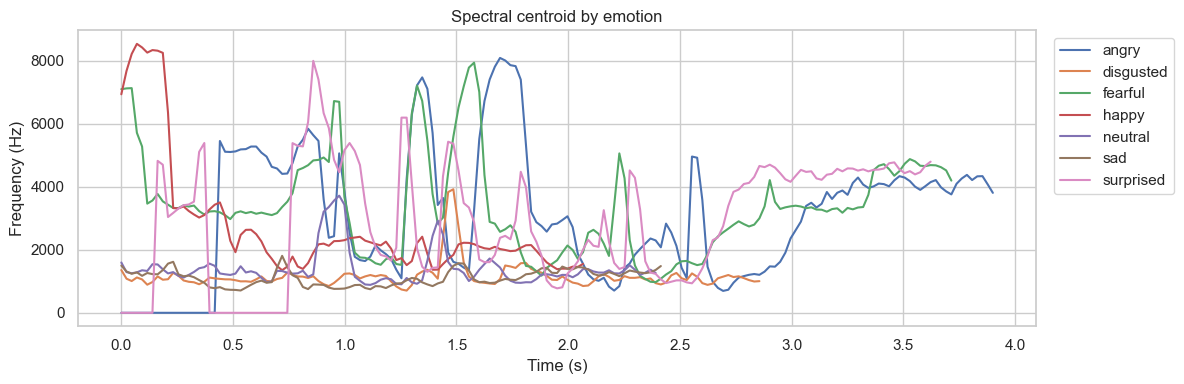

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
for emotion in EMOTION_LIST:
    y, sr    = clips[emotion]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    times    = librosa.times_like(centroid, sr=sr)
    ax.plot(times, centroid, label=emotion)
ax.set_title('Spectral centroid by emotion')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6.7 Zero-crossing rate

Zero-crossing rate counts how often the waveform crosses zero amplitude per frame. It is high for fricatives and noisy segments (Angry, Fearful) and low for voiced, sustained vowels (Sad, Neutral).

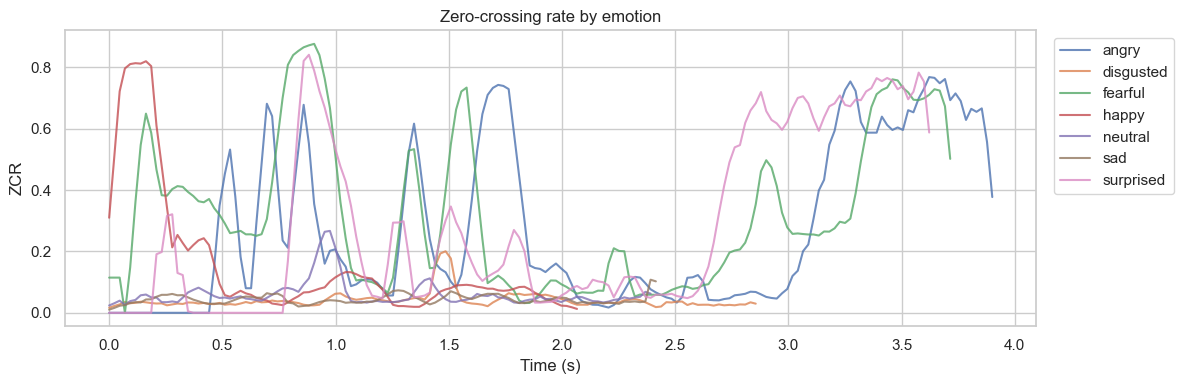

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
for emotion in EMOTION_LIST:
    y, sr = clips[emotion]
    zcr   = librosa.feature.zero_crossing_rate(y)[0]
    times = librosa.times_like(zcr, sr=sr)
    ax.plot(times, zcr, label=emotion, alpha=0.8)
ax.set_title('Zero-crossing rate by emotion')
ax.set_xlabel('Time (s)')
ax.set_ylabel('ZCR')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6.8 Chroma

Chroma features represent energy across the 12 pitch classes (C, C#, …, B). They are a music feature designed for tonal harmony — expect weak, noisy patterns in speech data, which will be confirmed by the ANOVA ranking in Section 7.

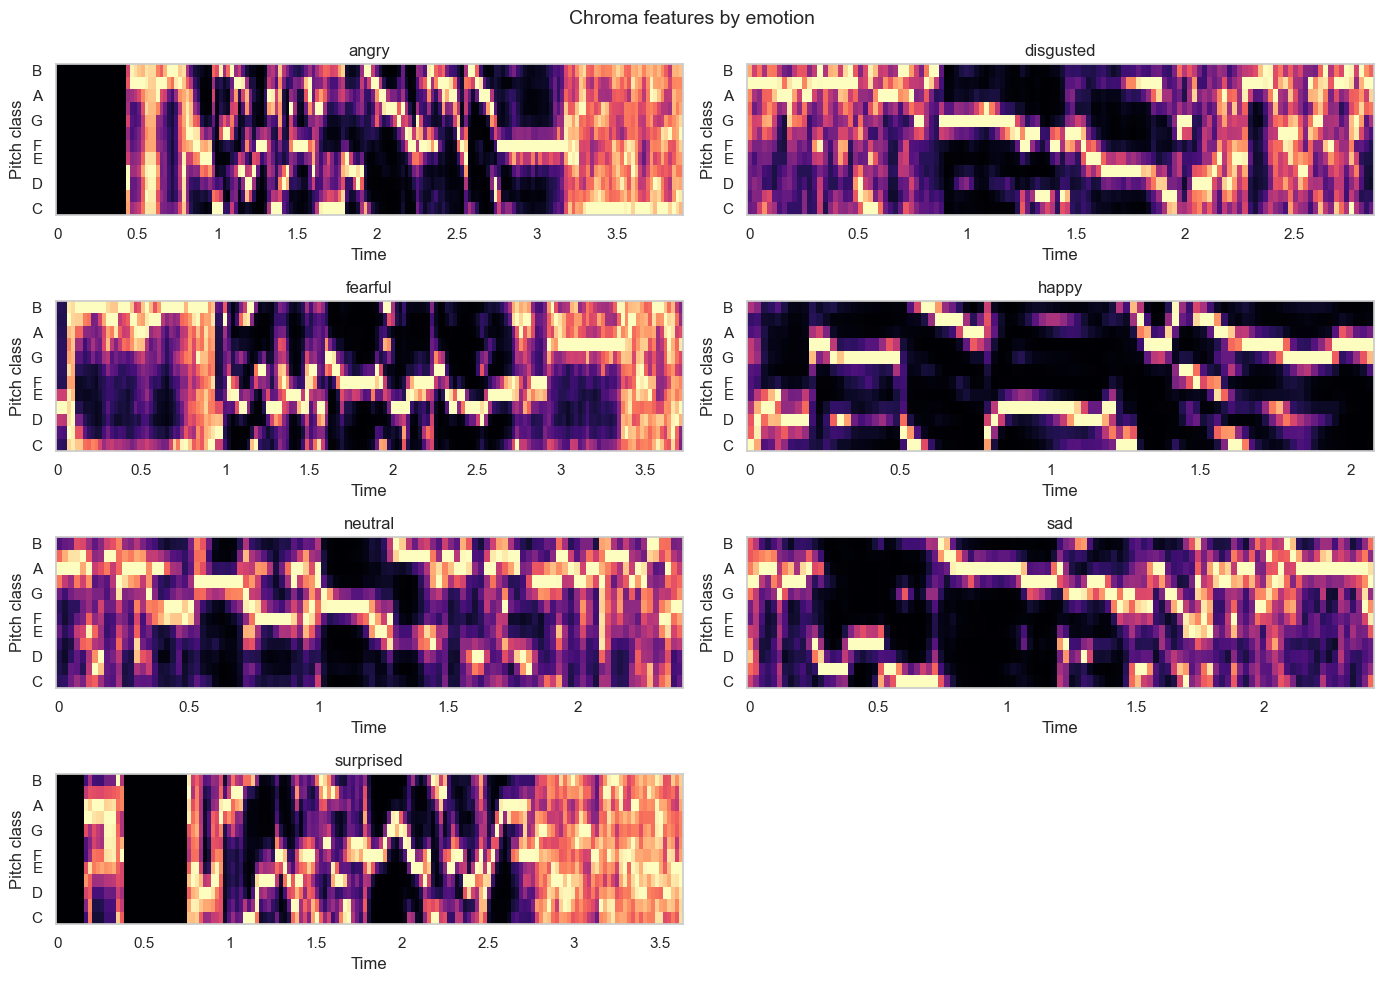

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
for ax, emotion in zip(axes.ravel(), EMOTION_LIST):
    y, sr  = clips[emotion]
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    librosa.display.specshow(chroma, sr=sr, ax=ax, x_axis='time', y_axis='chroma')
    ax.set_title(emotion)
axes.ravel()[-1].axis('off')
fig.suptitle('Chroma features by emotion', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Feature discrimination — which features actually separate the emotions?

Visual inspection of one clip per emotion is suggestive but not conclusive. To decide which features to use in Sprint 2 we need to measure how well each feature separates emotions *across many clips*. We use one-way ANOVA F-statistic: higher F means the between-group variance (emotion group means) is large relative to the within-group variance (spread within each emotion).

In [16]:
SAMPLE_PER_EMOTION = 100
feat_sample = (
    df[df['source'] != 'SAVEE']
    .groupby('emotion')
    .sample(n=SAMPLE_PER_EMOTION, random_state=42)
)

feature_rows = []
for i, (_, row) in enumerate(feat_sample.iterrows()):
    if i % 50 == 0:
        print(f'  extracting features ... {i}/{len(feat_sample)}')
    try:
        y, sr = librosa.load(row['file_path'], sr=22050)

        rms      = librosa.feature.rms(y=y)[0]
        f0, voiced_flag, _ = librosa.pyin(
            y, fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'), hop_length=1024
        )
        f0_voiced = f0[voiced_flag]
        zcr       = librosa.feature.zero_crossing_rate(y)[0]
        centroid  = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        mfccs     = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        chroma    = librosa.feature.chroma_stft(y=y, sr=sr)

        feat = {
            'emotion':       row['emotion'],
            'rms_mean':      float(np.mean(rms)),
            'f0_mean':       float(np.mean(f0_voiced)) if len(f0_voiced) > 0 else float('nan'),
            'f0_std':        float(np.std(f0_voiced))  if len(f0_voiced) > 0 else float('nan'),
            'zcr_mean':      float(np.mean(zcr)),
            'centroid_mean': float(np.mean(centroid)),
        }
        for i_m in range(13):
            feat[f'mfcc_{i_m+1}_mean'] = float(np.mean(mfccs[i_m]))
        for i_c in range(12):
            feat[f'chroma_{i_c+1}_mean'] = float(np.mean(chroma[i_c]))

        feature_rows.append(feat)
    except Exception:
        pass

feat_df = pd.DataFrame(feature_rows).dropna(subset=['f0_mean'])
print(f'\nFeature table: {feat_df.shape[0]} clips x {feat_df.shape[1]-1} features')
feat_df.head()

  extracting features ... 0/700


  extracting features ... 50/700


  extracting features ... 100/700


  extracting features ... 150/700


  extracting features ... 200/700


...

  extracting features ... 550/700


  extracting features ... 600/700


  extracting features ... 650/700



Feature table: 680 clips x 30 features


,emotion,rms_mean,f0_mean,f0_std,zcr_mean,centroid_mean,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,...,chroma_3_mean,chroma_4_mean,chroma_5_mean,chroma_6_mean,chroma_7_mean,chroma_8_mean,chroma_9_mean,chroma_10_mean,chroma_11_mean,chroma_12_mean
0,angry,0.018963,496.574882,517.378255,0.146656,2409.784250,-451.056641,69.850281,-26.833439,15.284448,...,0.397150,0.462892,0.605439,0.528771,0.431794,0.420806,0.447975,0.386345,0.359334,0.450692
1,angry,0.040041,351.354036,81.005627,0.091243,1677.951133,-353.706390,102.908554,-4.306861,19.329933,...,0.337607,0.374874,0.323976,0.291398,0.288915,0.433337,0.500677,0.587465,0.513591,0.393687
2,angry,0.046392,184.430639,43.713014,0.061222,1425.531096,-316.664825,121.677025,0.878854,40.481575,...,0.286496,0.300348,0.367517,0.320904,0.451443,0.505241,0.444249,0.420166,0.483357,0.343863
3,angry,0.014482,172.818009,27.553062,0.312534,2954.677856,-504.023071,49.689072,-18.918953,7.379282,...,0.372399,0.416559,0.483553,0.593992,0.485388,0.468160,0.393679,0.360560,0.339711,0.402604
4,angry,0.033594,146.098425,28.965321,0.052043,1271.418563,-354.797150,130.035599,9.240149,38.693020,...,0.300873,0.428182,0.488689,0.334207,0.478491,0.510295,0.427260,0.455049,0.497140,0.466797


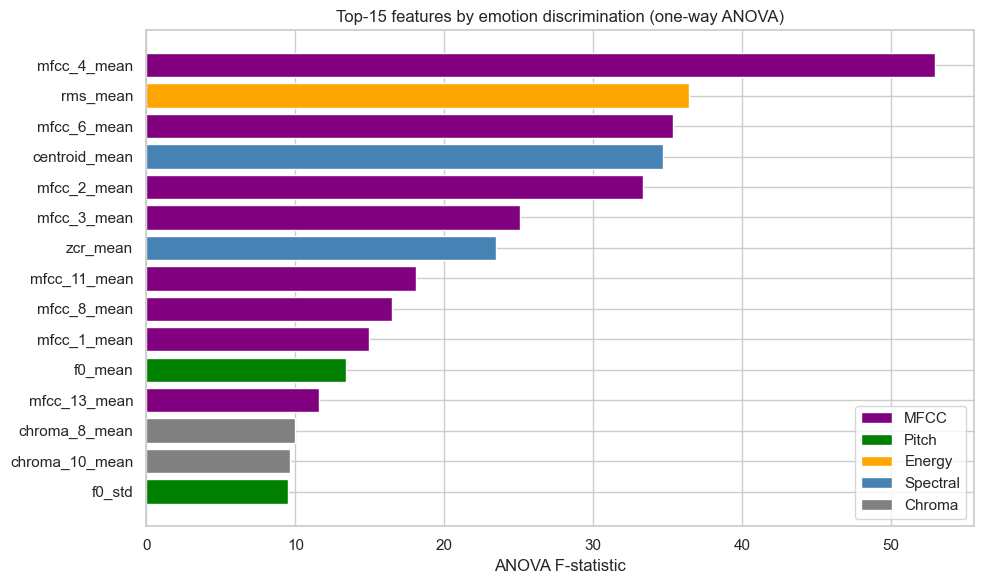

Top-10 discriminating features:
      feature         F            p
  mfcc_4_mean 52.919708 1.965231e-53
     rms_mean 36.417780 2.841510e-38
  mfcc_6_mean 35.339582 3.150215e-37
centroid_mean 34.650687 1.477689e-36
  mfcc_2_mean 33.356824 2.742479e-35
  mfcc_3_mean 25.061162 6.626941e-27
     zcr_mean 23.454268 3.134196e-25
 mfcc_11_mean 18.127239 1.468083e-19
  mfcc_8_mean 16.520403 8.164277e-18
  mfcc_1_mean 14.954171 4.240613e-16


In [17]:
feature_cols = [c for c in feat_df.columns if c != 'emotion']
emotion_groups = feat_df['emotion'].unique()

anova_results = []
for col in feature_cols:
    groups = [
        feat_df[feat_df['emotion'] == e][col].dropna().values
        for e in emotion_groups
    ]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) >= 2:
        f_stat, p_val = stats.f_oneway(*groups)
        anova_results.append({'feature': col, 'F': f_stat, 'p': p_val})

anova_df = (
    pd.DataFrame(anova_results)
    .sort_values('F', ascending=False)
    .reset_index(drop=True)
)

def feature_family(name):
    if name.startswith('mfcc'):    return 'MFCC'
    if name.startswith('f0'):      return 'Pitch'
    if name.startswith('rms'):     return 'Energy'
    if name.startswith('chroma'):  return 'Chroma'
    return 'Spectral'

color_map = {
    'MFCC':     'purple',
    'Pitch':    'green',
    'Energy':   'orange',
    'Spectral': 'steelblue',
    'Chroma':   'gray',
}

top15  = anova_df.head(15)
colors = [color_map[feature_family(f)] for f in top15['feature']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15['feature'][::-1], top15['F'][::-1], color=colors[::-1])
ax.set_xlabel('ANOVA F-statistic')
ax.set_title('Top-15 features by emotion discrimination (one-way ANOVA)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print('Top-10 discriminating features:')
print(anova_df.head(10)[['feature', 'F', 'p']].to_string(index=False))

## 8. Conclusions for Sprint 2 preprocessing

1. **Four corpora, not two.** The dataset merges TESS, RAVDESS, CREMA-D, and SAVEE. CREMA-D is the largest contributor.

2. **SAVEE folder labels are wrong.** Files were placed across emotion folders by speaker, not by emotion. Relabel SAVEE clips from the filename prefix, or drop those 480 files entirely to avoid poisoning the training set.

3. **Standardize sample rate down to 16 kHz.** CREMA-D's native rate is the floor. Upsampling TESS (24414 Hz), RAVDESS (48 kHz), and SAVEE (44.1 kHz) to a higher common rate adds no information. Downsample everything to 16 kHz for honest, equal bandwidth.

4. **MFCCs are the backbone feature.** Low-order coefficients (especially MFCC 2–5) are the strongest individual emotion discriminators by ANOVA F-statistic. They should form the primary feature vector in Sprint 2.

5. **RMS energy and mean F0 are cheap, strong supplemental features.** Both rank just below the top MFCCs and capture arousal directly. Include them.

6. **Drop chroma.** Chroma ranks last across every emotion group. It is a music harmony feature that does not transfer meaningfully to speech emotion data.

7. **Class imbalance: Suprised is the smallest class.** CREMA-D has no surprise category, so Suprised clips come only from TESS, RAVDESS, and SAVEE. Sprint 3 will need weighted loss or oversampling to compensate.